# Run simulation

## 1. Preamble:
- Load packages of interest.
- Include necessary scripts.

In [1]:
## packages to be used
using CSV
using DataFrames
using Random
using Parameters
using Distributions
using StatsBase
using Plots

In [2]:
include("import.jl")
include("params.jl")
include("model.jl")
include("setup.jl")

setup_sim (generic function with 1 method)

## 2. Generate a *Simulation* struct with the following properties:
- *pop*: population of agents.
- *lamp_data*: micro level data. It will be used to fill the object *pop*.
- *cohort*: population arraned by birth cohort.
- (Internal note: data type is complicated and might change => keep as parameter.)

In [4]:
mutable struct Simulation{DT}
    pop :: Vector{Person}
	# person_id => [person_years]
	lamp_data :: Dict{String, DT} # slot to be used by the "DataFrame row type"
	# year => number of active persons
	cohort :: Vector{Int}
	# year => [person_years]
	cohort_pop :: Vector{Vector{DT}}
end

## 3. Run simulation by doing **six tasks**:
1) Load data
    - Load micro data. By doing this, the load_lamp function gives us the start and end of our microlevel data.
    - Load macro data. We also get the constant values regarding start and end of macro data.
    - rescaled: calendar year for which we have both micro and macro data.
2) *override_micro_factors* and *override_macro_factors* if interested in alternative scenarios.

3)   Generate unified version of factors and parameters. Basically pasting togeter micro and macro values, as well as statistical model coefficients.
4) Generate a *sim* object using the *setup_sim* function (see setup.)
5) Update agents for y number years.
6) Compute counts and rates.
    - Similarly to a "thereotical" ABM, create empty vectors to contain information on counts and rates.
    - Function outputs are all this vectors with information on counts and rates.
- **Function fields**: 
    - paths to micro and macro data, statistical model coefficients.
    - number of years for which the simulation will run.
    - random seed to ensure replicability.
    - Destination of interest.
    - Potentially, override micro and macro factor to explore alternative scenarios.
    - Use survey weights.


In [5]:
function run_sim(path_micro, path_macro, path_stats, years, seed, dest,
	override_micro_factors, override_macro_factors; use_weights = true, verbose = false)

	lamp, start_micro, end_micro = load_lamp(path_stats, path_micro) # add local values on min and max as return values.
	macro_values, start_macro, end_macro = load_macro(path_stats, path_macro)
	rescaled = start_macro - start_micro + 1
	micro_factors, macro_factors, offset = load_stats(path_stats, dest)

	# change factors from data (scenarios)
	for (key, value) in override_micro_factors
		micro_factors[key] = value
	end

	for (key, value) in override_macro_factors
		macro_factors[key] = value
	end

	# final values to be used in decision model
	factors = vcat(offset, micro_factors, macro_factors)
	parameters = Params(length(lamp), factors, macro_values)

	#Creating population and sim objects.
	sim = setup_sim(lamp, seed, use_weights = use_weights)

	d_mig = Int[]
	n_nomig = Int[]
	n_dead = Int[]
	#mean_probs = Float64[]

	for year in 1:years
		# add if to exclude agents lower than min macro. add min macro as parameter of update agents.
		add_agents!(sim.cohort_pop[year], sim.pop, use_weights = use_weights)
		if year >= rescaled # dont update agents before start_macro
			#nmigration_events, mean_prob = update_agents!(sim, year, parameters, start_micro, start_macro)
			nmigration_events = update_agents!(sim, year, parameters, start_micro, start_macro)
			push!(d_mig, nmigration_events)
		else
			push!(d_mig, 0)
		end
		#push!(n_mig, count(p -> p.status == migrant, sim.pop))
		push!(n_nomig, count(p -> p.status != migrant && p.status != inactive, sim.pop))
		push!(n_dead, count(p -> p.status == inactive, sim.pop))
		if verbose
			println(year, ", ", n_mig[end], ", ", n_nomig[end])
	   end
   	end
	n_mig = cumsum(d_mig)
	#d_mig = n_mig[2:end] .- n_mig[1:end-1]
	@assert length(d_mig) == years
	@assert length(n_nomig) == years
	#n_mig, n_nomig, d_mig./n_nomig, sim.pop, sim.cohort, d_mig, n_dead, mean_probs
	# change in cummit rate.
	n_mig, n_nomig, d_mig./(d_mig .+ n_nomig), n_mig./(n_mig .+ n_nomig), sim.pop, sim.cohort, d_mig, n_dead, rescaled
end

run_sim (generic function with 1 method)

## 4. Generate functions to analyze data easily. 
- Alternatively include this in a separate file *analysis.jl*.
- Transform vectors to dataframes.
- Compute RMSE to compare default model with alternative scenarios.

In [6]:
# Transform vector seeds to data frames
function DF_rates(vector_rates)
	df = DataFrame(zeros(length(vector_rates[1]), length(vector_rates)), :auto) 

	for index in 1:length(vector_rates)
	df[:, index] = vector_rates[index]
	end
	df
end

# RMSE function
function RMSE(empirical_rate, estimated_rate)
	rmse_1 =  sqrt(sum((empirical_rate - estimated_rate).^2) / (length(empirical_rate)))
end

RMSE (generic function with 1 method)

## 5. Generate a new run function to simulate multiple random seeds more efficiently.
- It uses *run_sim* function.
- Loop is contained within *run_seeds* function.
- Empty vectors are now vectors of vectors. Basically each seed will be one vector.

In [7]:
function run_seeds(path_micro, path_macro, path_stats, override_micro_factors, override_macro_factors, nb_of_seeds)

# Empty vectors where to put each of the seeds results. 
	# Vector will contain one-dimension vectors. 
	vector_n_mig = []
	vector_mig_rate = []
	vector_cummig_rate = []
	
# Run simulation x number of times ("nb_seeds") of times.
	# Only request mig_rates and cummig_rates
	for seed in 1:nb_of_seeds
		n_mig, n_nomig, mig_rate, cummig_rate, pop, cohort, d_mig, n_dead, rescaled = run_sim(path_micro, path_macro, path_stats, 78, seed, "Spain", override_micro_factors, override_macro_factors);
		push!(vector_n_mig, n_mig[32:end])
		push!(vector_mig_rate, mig_rate[32:end])
		push!(vector_cummig_rate, cummig_rate[32:end])
	end
	vector_vars = []
	push!(vector_vars, vector_n_mig)
	push!(vector_vars, vector_mig_rate)
	push!(vector_vars, vector_cummig_rate)

	# Loop across vector_vars to 
	vec_dfs = []
	for vec in vector_vars 
		push!(vec_dfs, DF_rates(vec))
	end

	vec_dfs

end



run_seeds (generic function with 1 method)

## 6. Default model: purely based on fitted coeficients.

In [ ]:
const scenario_micro_default = Dict()
const scenario_macro_default = Dict()

const vector_n_mig_default = []
const vector_mig_rate_default = []
const vector_cummig_rate_default = []
for seed in 1:10
	n_mig, n_nomig, mig_rate, cummig_rate, pop, cohort, d_mig, n_dead, rescaled = run_sim("lampABM.csv", "macro.csv", "stat_model_lampABM_mlogit.csv", 78, seed, "Spain", scenario_micro_default, scenario_macro_default);
	push!(vector_n_mig_default, n_mig[32:end]) # 1962 to 2008
	push!(vector_cummig_rate_default, cummig_rate[32:end])
	push!(vector_mig_rate_default, mig_rate[32:end])
end


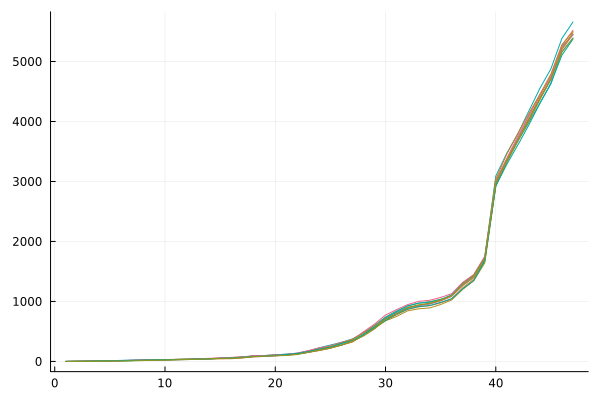

In [14]:
Plots.plot(vector_n_mig_default, labels = ["migrants"], legend = false)

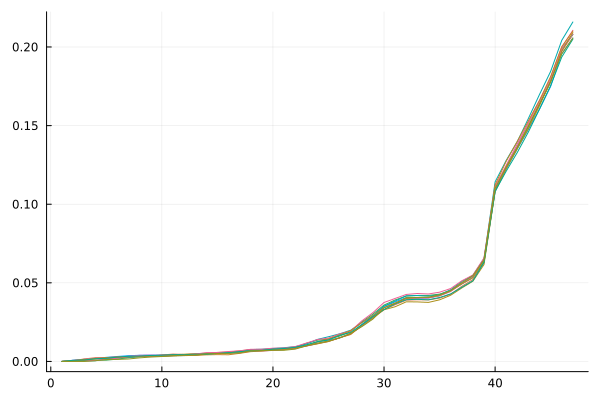

In [13]:
Plots.plot(vector_cummig_rate_default, labels = ["migrants"], legend = false)

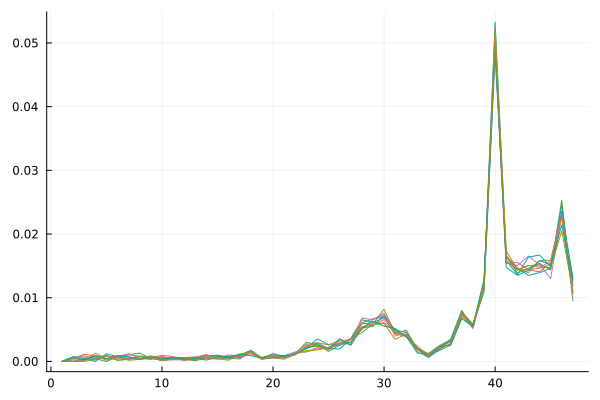

In [15]:
Plots.plot(vector_mig_rate_default, labels = ["mig_rate"], legend = false)